In [3]:
import json
import math
import sys
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F

sys.path.insert(0, str(Path.cwd().parent))

from eecs148b_hw1.tokenizer import TransformerLM


In [4]:
config = {
    'train_path': Path.cwd().parent / 'data' / 'tinystories_train_tokens.npy',
    'val_path': Path.cwd().parent / 'data' / 'tinystories_valid_tokens.npy',
    'checkpoint_path': Path.cwd() / 'checkpoints' / 'transformer_lm.pt',
    'experiment_root': Path.cwd() / 'runs',
    'run_name': f"run_{int(time.time())}",
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'dtype': torch.float32,
    'vocab_size': 10000,
    'context_length': 256,
    'd_model': 512,
    'num_layers': 4,
    'num_heads': 8,
    'd_ff': 2048,
    'batch_size': 32,
    'learning_rate': 3e-4,
    'weight_decay': 0.01,
    'max_steps': 5000,
    'eval_interval': 100,
    'eval_batches': 20,
    'log_interval': 10,
    'grad_clip': 1.0,
    'seed': 0,
}

torch.manual_seed(config['seed'])
np.random.seed(config['seed'])
config['checkpoint_path'].parent.mkdir(parents=True, exist_ok=True)
run_dir = config['experiment_root'] / config['run_name']
run_dir.mkdir(parents=True, exist_ok=True)
config['checkpoint_path'] = run_dir / config['checkpoint_path'].name
config


{'train_path': PosixPath('/Users/andrewzabelo/Desktop/hw1/data/tinystories_train_tokens.npy'),
 'val_path': PosixPath('/Users/andrewzabelo/Desktop/hw1/data/tinystories_valid_tokens.npy'),
 'checkpoint_path': PosixPath('/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958/transformer_lm.pt'),
 'experiment_root': PosixPath('/Users/andrewzabelo/Desktop/hw1/tests/runs'),
 'run_name': 'run_1776407958',
 'device': 'cpu',
 'dtype': torch.float32,
 'vocab_size': 10000,
 'context_length': 256,
 'd_model': 512,
 'num_layers': 4,
 'num_heads': 8,
 'd_ff': 2048,
 'batch_size': 32,
 'learning_rate': 0.0003,
 'weight_decay': 0.01,
 'max_steps': 5000,
 'eval_interval': 100,
 'eval_batches': 20,
 'log_interval': 10,
 'grad_clip': 1.0,
 'seed': 0}

In [5]:
train_data = np.load(config['train_path'], mmap_mode='r')
val_data = np.load(config['val_path'], mmap_mode='r')

config['vocab_size'] = max(config['vocab_size'], int(max(train_data.max(), val_data.max())) + 1)

print(train_data.shape, train_data.dtype)
print(val_data.shape, val_data.dtype)
print(config['vocab_size'])


(545600227,) int16
(5501911,) int16
10001


In [6]:
def get_batch_memmap(dataset, batch_size, context_length, device):
    max_start = len(dataset) - context_length - 1
    starts = np.random.randint(0, max_start + 1, size=batch_size)
    x = np.stack([dataset[s : s + context_length] for s in starts]).astype(np.int64)
    y = np.stack([dataset[s + 1 : s + context_length + 1] for s in starts]).astype(np.int64)
    return torch.from_numpy(x).to(device), torch.from_numpy(y).to(device)


def to_jsonable(value):
    if isinstance(value, dict):
        return {k: to_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_jsonable(v) for v in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, torch.dtype):
        return str(value)
    if isinstance(value, np.dtype):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().tolist()
    return value


history = []


def log_event(event):
    event = to_jsonable(event)
    history.append(event)
    log_path = run_dir / 'metrics.jsonl'
    with log_path.open('a', encoding='utf-8') as f:
        f.write(json.dumps(event) + '\n')


@torch.no_grad()
def estimate_split_loss(model, dataset, eval_batches, batch_size, context_length, device):
    model.eval()
    losses = []
    for _ in range(eval_batches):
        x, y = get_batch_memmap(dataset, batch_size, context_length, device)
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def save_checkpoint(path, model, optimizer, step, config):
    torch.save(
        {
            'step': step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config,
        },
        path,
    )


In [7]:
model = TransformerLM(
    vocab_size=config['vocab_size'],
    context_length=config['context_length'],
    d_model=config['d_model'],
    num_layers=config['num_layers'],
    num_heads=config['num_heads'],
    d_ff=config['d_ff'],
).to(config['device'])

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay'],
)

sum(p.numel() for p in model.parameters())


22833152

In [8]:
start_time = time.time()
model.train()
config_to_save = to_jsonable(config)
with (run_dir / 'config.json').open('w', encoding='utf-8') as f:
    json.dump(config_to_save, f, indent=2)
log_event({'step': 0, 'wallclock_time': 0.0, 'event': 'run_start'})

for step in range(1, config['max_steps'] + 1):
    x, y = get_batch_memmap(
        train_data,
        batch_size=config['batch_size'],
        context_length=config['context_length'],
        device=config['device'],
    )

    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
    optimizer.step()

    if step % config['log_interval'] == 0:
        elapsed = time.time() - start_time
        log_event({'step': step, 'wallclock_time': elapsed, 'train_loss': loss.item(), 'event': 'train'})
        print(f"step={step} train_loss={loss.item():.4f} elapsed={elapsed:.1f}s")

    if step % config['eval_interval'] == 0:
        train_eval = estimate_split_loss(
            model,
            train_data,
            eval_batches=config['eval_batches'],
            batch_size=config['batch_size'],
            context_length=config['context_length'],
            device=config['device'],
        )
        val_eval = estimate_split_loss(
            model,
            val_data,
            eval_batches=config['eval_batches'],
            batch_size=config['batch_size'],
            context_length=config['context_length'],
            device=config['device'],
        )
        elapsed = time.time() - start_time
        log_event(
            {
                'step': step,
                'wallclock_time': elapsed,
                'train_eval_loss': train_eval,
                'val_loss': val_eval,
                'event': 'eval',
            }
        )
        print(f"eval step={step} train_loss={train_eval:.4f} val_loss={val_eval:.4f}")
        save_checkpoint(config['checkpoint_path'], model, optimizer, step, config)

save_checkpoint(config['checkpoint_path'], model, optimizer, config['max_steps'], config)
log_event({'step': config['max_steps'], 'wallclock_time': time.time() - start_time, 'event': 'run_end'})
print(config['checkpoint_path'])


step=10 train_loss=7.1384 elapsed=29.2s
step=20 train_loss=5.9171 elapsed=70.0s
step=30 train_loss=5.2790 elapsed=107.3s
step=40 train_loss=4.8391 elapsed=150.4s
step=50 train_loss=4.4844 elapsed=184.4s
step=60 train_loss=4.4283 elapsed=222.8s


KeyboardInterrupt: 

In [9]:
from eecs148b_hw1.tokenizer import Tokenizer

tokenizer = Tokenizer.from_files(
    Path.cwd() / 'vocab.pkl',
    Path.cwd() / 'merges.pkl',
    ['<|endoftext|>'],
)
eot_token_id = tokenizer.reverse_vocab[b'<|endoftext|>']


@torch.no_grad()
def generate_completion(model, tokenizer, prompt, max_new_tokens=64, temperature=1.0, top_p=0.9):
    model.eval()

    token_ids = tokenizer.encode(prompt)
    x = torch.tensor([token_ids], dtype=torch.long, device=config['device'])

    for _ in range(max_new_tokens):
        x_cond = x[:, -config['context_length'] :]
        logits = model(x_cond)
        next_token_logits = logits[:, -1, :]

        if temperature <= 0:
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        else:
            scaled_logits = next_token_logits / temperature
            probs = torch.softmax(scaled_logits, dim=-1)

            sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            nucleus_mask = cumulative_probs <= top_p
            nucleus_mask[..., 0] = True

            filtered_probs = torch.where(nucleus_mask, sorted_probs, torch.zeros_like(sorted_probs))
            filtered_probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

            sampled_idx = torch.multinomial(filtered_probs, num_samples=1)
            next_token = sorted_indices.gather(-1, sampled_idx)

        x = torch.cat([x, next_token], dim=-1)

        if next_token.item() == eot_token_id:
            break

    return tokenizer.decode(x[0].tolist())


In [10]:
prompt = 'Once upon a time'
generated_text = generate_completion(
    model,
    tokenizer,
    prompt,
    max_new_tokens=256,
    temperature=0.99,
    top_p=0.9,
)
print(generated_text)


Once upon a time, Tom went all all the happy.
<|endoftext|>


[{'step': 10, 'wallclock_time': 29.17313504219055, 'train_loss': 7.138430118560791, 'event': 'train'}, {'step': 20, 'wallclock_time': 70.02560901641846, 'train_loss': 5.917108058929443, 'event': 'train'}, {'step': 30, 'wallclock_time': 107.34292197227478, 'train_loss': 5.278975963592529, 'event': 'train'}]


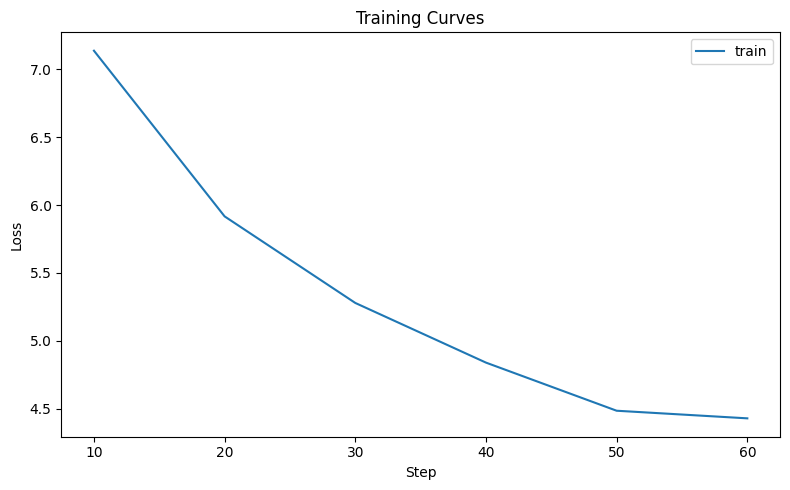

/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958/loss_curves.png
/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958
/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958/config.json
/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958/metrics.jsonl
/Users/andrewzabelo/Desktop/hw1/tests/runs/run_1776407958/loss_curves.json


In [11]:
eval_history = [event for event in history if event.get('event') == 'eval']
train_history = [event for event in history if event.get('event') == 'train']

curve_data = {
    'train': [{'step': event['step'], 'loss': event['train_loss']} for event in train_history],
    'train_eval': [{'step': event['step'], 'loss': event['train_eval_loss']} for event in eval_history],
    'val': [{'step': event['step'], 'loss': event['val_loss']} for event in eval_history],
}

print(train_history[:3])

curve_json_path = run_dir / 'loss_curves.json'
with curve_json_path.open('w', encoding='utf-8') as f:
    json.dump(curve_data, f, indent=2)

try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    if train_history:
        plt.plot([event['step'] for event in train_history], [event['train_loss'] for event in train_history], label='train')
    if eval_history:
        plt.plot([event['step'] for event in eval_history], [event['train_eval_loss'] for event in eval_history], label='train_eval')
        plt.plot([event['step'] for event in eval_history], [event['val_loss'] for event in eval_history], label='val')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Curves')
    plt.legend()
    plt.tight_layout()

    curve_path = run_dir / 'loss_curves.png'
    plt.savefig(curve_path)
    plt.show()
    print(curve_path)
except ModuleNotFoundError:
    print('matplotlib not installed; saved curve data only')

print(run_dir)
print(run_dir / 'config.json')
print(run_dir / 'metrics.jsonl')
print(curve_json_path)


In [ ]:
eval_history = [event for event in history if event.get('event') == 'eval']
train_history = [event for event in history if event.get('event') == 'train']

curve_data = {
    'train': [{'step': event['step'], 'loss': event['train_loss']} for event in train_history],
    'train_eval': [{'step': event['step'], 'loss': event['train_eval_loss']} for event in eval_history],
    'val': [{'step': event['step'], 'loss': event['val_loss']} for event in eval_history],
}

print(train_history[:3])